[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/06_predictive_validation_and_perturbation.ipynb)

# Step 06 — Predictive validation and perturbation robustness

This notebook runs the local Step 06 pipeline without Google Drive dependencies and writes auditable outputs under `outputs/predictive_validation/`.

**Claim scope:** Step 06 may support a predictive/perturbation robustness screen, but it does not by itself authorize final biological degeneracy wording. Later assumption-sensitivity and parameter-plausibility steps remain required.

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
PROJECT_ROOT

PosixPath('/workspace/astromodel_proving')

In [2]:
from src.step06_predictive_validation import Step06Config, run_step06_predictive_validation

config = Step06Config(max_candidates=2, time_points=50, write_outputs=True)
result = run_step06_predictive_validation(PROJECT_ROOT, config)
result["analysis_summary"]

{'step_name': 'Step 06 — Predictive validation and perturbation robustness',
 'config': {'max_candidates': 2,
  'time_points': 50,
  't_final_ms': 50000.0,
  'prediction_interval_quantiles': (0.05, 0.5, 0.95),
  'min_holdout_pass_fraction': 0.3,
  'max_trace_rmse_mV': 25.0,
  'perturbation_current_na': None,
  'perturbation_factors': {'nominal': 1.0,
   'eps_scale_low': 0.5,
   'eps_scale_high': 1.5,
   'stimulus_duration_short': 0.75,
   'stimulus_duration_long': 1.25,
   'baseline_K_o_low': 0.95,
   'baseline_K_o_high': 1.05,
   'current_scale_low': 0.9,
   'current_scale_high': 1.1},
  'robustness_recovery_error_max': 1.5,
  'robustness_peak_ratio_max': 1.75,
  'min_robust_fraction': 0.5,
  'write_outputs': True,
  'require_candidate_level_heldout': True,
  'final_degeneracy_claim_allowed': False},
 'n_candidates': 1,
 'n_heldout_rows': 8,
 'n_prediction_interval_rows': 54,
 'n_ppc_rows': 54,
 'n_perturbation_rows': 9,
 'validation_labels': ['insufficient_evidence'],
 'headline_clai

## Accepted ensemble and mechanism inventory

In [3]:
heldout = result["heldout_current_errors"]
heldout[["file_id", "region", "condition", "candidate_id", "mechanism_cluster"]].drop_duplicates().head(10)

,file_id,region,condition,candidate_id,mechanism_cluster
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,M1


## Held-out-current error table

In [4]:
heldout.head(12)

,file_id,region,condition,candidate_id,sweep,current_na,split_strategy,heldout_trace_rmse_mV,heldout_weighted_feature_pass_fraction,holdout_status,prediction_status,prediction_pass,mechanism_cluster,mechanism_label_status
0,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,1,50,leave_one_current_out,3.554267,0.355493,passed,predictive_pass,True,M1,step05_label_available
1,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,2,75,leave_one_current_out,3.554267,0.355493,passed,predictive_pass,True,M1,step05_label_available
2,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,3,100,leave_one_current_out,3.554267,0.355493,passed,predictive_pass,True,M1,step05_label_available
3,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,4,125,leave_one_current_out,3.554267,0.355493,passed,predictive_pass,True,M1,step05_label_available
4,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,5,150,leave_one_current_out,3.554267,0.355493,passed,predictive_pass,True,M1,step05_label_available
5,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,6,175,leave_one_current_out,3.554267,0.355493,passed,predictive_pass,True,M1,step05_label_available
6,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,-1,162,low_to_high,3.554267,0.355493,stress_test_screen,predictive_pass,True,M1,step05_label_available
7,1_DH_1_CONTROL,DH,CONTROL,1_DH_1_CONTROL__cand_01,-1,62,high_to_low,3.554267,0.355493,stress_test_screen,predictive_pass,True,M1,step05_label_available


## Prediction interval table and figure

In [5]:
intervals = result["prediction_intervals"]
intervals.head(12)

,region,condition,sweep,current_na,feature,n_predictions,n_source_candidates,source_candidate_ids,pi_lower,pi_median,pi_upper,interval_quantiles
0,DH,CONTROL,1,50,decay_slope_mV_per_s,1,1,1_DH_1_CONTROL__cand_01,-2.432116e-04,-2.432116e-04,-2.432116e-04,"0.05,0.5,0.95"
1,DH,CONTROL,1,50,decay_tau_s,1,1,1_DH_1_CONTROL__cand_01,1.113475e+04,1.113475e+04,1.113475e+04,"0.05,0.5,0.95"
2,DH,CONTROL,1,50,peak_depolarization_mV,1,1,1_DH_1_CONTROL__cand_01,2.708100e+00,2.708100e+00,2.708100e+00,"0.05,0.5,0.95"
3,DH,CONTROL,1,50,plateau_slope_mV_per_s,1,1,1_DH_1_CONTROL__cand_01,-8.267893e-06,-8.267893e-06,-8.267893e-06,"0.05,0.5,0.95"
4,DH,CONTROL,1,50,return_slope_mV_per_s,1,1,1_DH_1_CONTROL__cand_01,-3.047892e-07,-3.047892e-07,-3.047892e-07,"0.05,0.5,0.95"
5,DH,CONTROL,1,50,rise_slope_mV_per_s,1,1,1_DH_1_CONTROL__cand_01,2.427851e-01,2.427851e-01,2.427851e-01,"0.05,0.5,0.95"
6,DH,CONTROL,1,50,rise_tau_s,1,1,1_DH_1_CONTROL__cand_01,1.115431e+01,1.115431e+01,1.115431e+01,"0.05,0.5,0.95"
7,DH,CONTROL,1,50,stim_end_depolarization_mV,1,1,1_DH_1_CONTROL__cand_01,2.702161e+00,2.702161e+00,2.702161e+00,"0.05,0.5,0.95"
8,DH,CONTROL,1,50,undershoot_magnitude_mV,1,1,1_DH_1_CONTROL__cand_01,1.969345e-02,1.969345e-02,1.969345e-02,"0.05,0.5,0.95"
9,DH,CONTROL,2,75,decay_slope_mV_per_s,1,1,1_DH_1_CONTROL__cand_01,-3.905110e-04,-3.905110e-04,-3.905110e-04,"0.05,0.5,0.95"


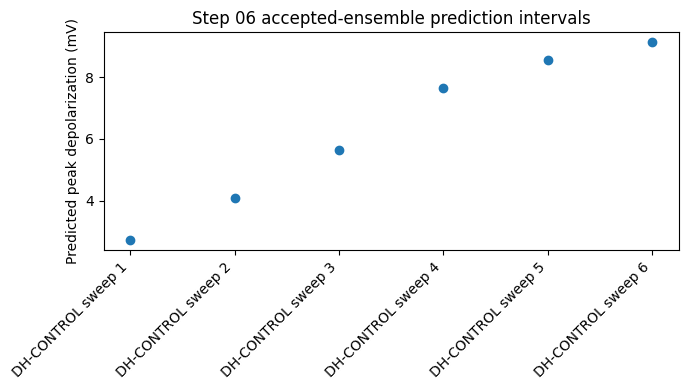

In [6]:
plot_df = intervals[intervals["feature"] == "peak_depolarization_mV"].copy()
fig, ax = plt.subplots(figsize=(7, 4))
if not plot_df.empty:
    labels = plot_df["region"].astype(str) + "-" + plot_df["condition"].astype(str) + " sweep " + plot_df["sweep"].astype(str)
    x = range(len(plot_df))
    ax.errorbar(x, plot_df["pi_median"], yerr=[plot_df["pi_median"] - plot_df["pi_lower"], plot_df["pi_upper"] - plot_df["pi_median"]], fmt="o")
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Predicted peak depolarization (mV)")
ax.set_title("Step 06 accepted-ensemble prediction intervals")
fig.tight_layout()

## Feature posterior predictive coverage

In [7]:
ppc = result["feature_distribution_ppc"]
ppc.sort_values(["region", "condition", "sweep", "feature"]).head(15)

,region,condition,sweep,feature,n_predictions,empirical_lower,empirical_upper,coverage_fraction,reliability_weight,weighted_coverage,threshold_fallback
0,DH,CONTROL,1,decay_slope_mV_per_s,1,-0.862333,19.373751,1.0,1.00,1.0,region_specific
1,DH,CONTROL,1,decay_tau_s,1,-0.019750,0.570250,0.0,1.00,0.0,region_specific
2,DH,CONTROL,1,peak_depolarization_mV,1,5.260867,9.464395,0.0,1.00,0.0,region_specific
3,DH,CONTROL,1,plateau_slope_mV_per_s,1,-0.102736,0.066363,1.0,1.00,1.0,region_specific
4,DH,CONTROL,1,return_slope_mV_per_s,1,0.015148,0.041789,0.0,1.00,0.0,region_specific
5,DH,CONTROL,1,rise_slope_mV_per_s,1,-1.460832,15.745257,1.0,1.00,1.0,region_specific
6,DH,CONTROL,1,rise_tau_s,1,-0.018250,0.727750,0.0,1.00,0.0,region_specific
7,DH,CONTROL,1,stim_end_depolarization_mV,1,4.284525,9.021125,0.0,0.45,0.0,region_pooled
8,DH,CONTROL,1,undershoot_magnitude_mV,1,-0.690360,2.762808,1.0,1.00,1.0,region_specific
9,DH,CONTROL,2,decay_slope_mV_per_s,1,-2.873914,28.937465,1.0,1.00,1.0,region_specific


## Perturbation robustness

In [8]:
perturb = result["perturbation_sweeps"]
perturb[["file_id", "region", "condition", "mechanism_cluster", "perturbation", "K_o_peak", "K_o_recovery_error", "robust_under_perturbation", "simulation_status"]].head(15)

,file_id,region,condition,mechanism_cluster,perturbation,K_o_peak,K_o_recovery_error,robust_under_perturbation,simulation_status
0,1_DH_1_CONTROL,DH,CONTROL,M1,nominal,6.617568,0.007898,True,ok
1,1_DH_1_CONTROL,DH,CONTROL,M1,eps_scale_low,5.895248,0.011932,True,ok
2,1_DH_1_CONTROL,DH,CONTROL,M1,eps_scale_high,6.999869,0.005645,True,ok
3,1_DH_1_CONTROL,DH,CONTROL,M1,stimulus_duration_short,NaN,NaN,False,unsupported
4,1_DH_1_CONTROL,DH,CONTROL,M1,stimulus_duration_long,NaN,NaN,False,unsupported
5,1_DH_1_CONTROL,DH,CONTROL,M1,baseline_K_o_low,6.617578,0.007925,True,ok
6,1_DH_1_CONTROL,DH,CONTROL,M1,baseline_K_o_high,6.617559,0.007870,True,ok
7,1_DH_1_CONTROL,DH,CONTROL,M1,current_scale_low,6.101125,0.007898,True,ok
8,1_DH_1_CONTROL,DH,CONTROL,M1,current_scale_high,7.141668,0.007898,True,ok


In [9]:
robustness = result["robustness_summary"]
robustness

,mechanism_cluster,region,condition,n_candidates,n_cells,holdout_pass_fraction,mean_weighted_ppc_coverage,perturbation_robust_fraction,step05_evidence_status,validation_label,step06_screen_claim,final_biological_degeneracy_claim_allowed,degeneracy_claim_allowed,claim_scope_after_step06
0,M1,DH,CONTROL,1,1,1.0,0.481481,1.0,insufficient_evidence,insufficient_evidence,mechanism_candidate_not_supported_by_step06_sc...,False,False,mechanism_candidate_not_supported_by_step06_sc...


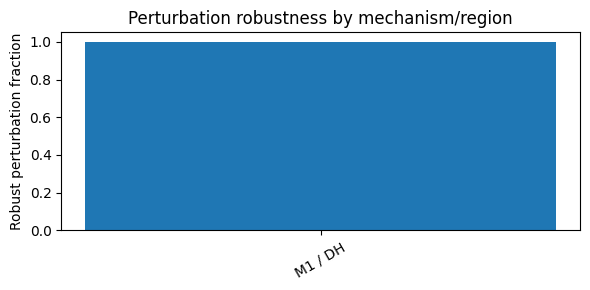

In [10]:
fig, ax = plt.subplots(figsize=(6, 3))
if not robustness.empty:
    robust_plot = robustness.copy()
    robust_plot["label"] = robust_plot["mechanism_cluster"].astype(str) + " / " + robust_plot["region"].astype(str)
    ax.bar(robust_plot["label"], robust_plot["perturbation_robust_fraction"].fillna(0.0))
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Robust perturbation fraction")
    ax.tick_params(axis="x", rotation=30)
ax.set_title("Perturbation robustness by mechanism/region")
fig.tight_layout()

## Claim scope after Step 06

The pipeline reports `predictive_supported`, `prediction_limited`, `fit_only`, or `insufficient_evidence`. It does **not** upgrade clusters to `candidate_degenerate_regimes` from Step 06 alone; any degeneracy wording requires mechanism distinction plus predictive/perturbation support and later assumption-sensitivity checks.

In [11]:
pd.DataFrame([result["analysis_summary"]])

,step_name,config,n_candidates,n_heldout_rows,n_prediction_interval_rows,n_ppc_rows,n_perturbation_rows,validation_labels,headline_claim_scope,elapsed_seconds
0,Step 06 — Predictive validation and perturbati...,"{'max_candidates': 2, 'time_points': 50, 't_fi...",1,8,54,54,9,[insufficient_evidence],Mechanism regimes require predictive_supported...,3.826234
